# Implementation of MNIST Multi-Layer Perceptron (MLP) with PyTorch.
---

## Objective
This notebook implements an MLP for MNIST digit classification using PyTorch
with the provided MnistDataloader class for reading IDX format files.

**Key Concepts:**

 - **MNIST**: A dataset of 70,000 handwritten digits (0-9), split into 60,000 training and 10,000 test images
 - **MLP (Multi-Layer Perceptron)**: A type of feedforward neural network with fully connected layers
 - **IDX format**: A simple binary format for storing multi-dimensional arrays, used by MNIST


### Data Processing Libraries

- **numpy:** Numerical operations on arrays
- **struct:** Reading binary data (IDX format)
- **array:** Efficient array storage for binary data

### PyTorch Components

- **torch:** Core tensor operations
- **torch.nn:** Neural network building blocks
- **torch.optim:** Optimization algorithms (Adam, SGD, etc.)
- **torch.nn.functional:** Functional versions of nn modules
- **Dataset, DataLoader:** Data pipeline utilities

### Visualization & Utilities

- **matplotlib.pyplot:** Plotting graphs and images
- **seaborn:** Statistical data visualization
- **tqdm:** Progress bars for loops
- **sklearn.metrics:** Model evaluation metrics

### Reproducibility

    torch.manual_seed(42)
    np.random.seed(42)

- Ensures the same random numbers each run
- Critical for debugging and sharing results

### Device Selection

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

- Automatically uses GPU if available
- Falls back to CPU otherwise
- All tensors/models must be on same device

In [1]:
# Import Required Libraries
import numpy as np
import struct
from array import array
from os.path import join
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. MNIST Data Loader Class

Custom class to read MNIST's binary IDX format.

### IDX Format Structure

- **Magic Number:** Identifies file type and dimensions and tells the computer exactly what the file is
- **Dimensions:** Number of items, rows, columns
- **Data:** Raw pixel values or labels

### Binary Reading Explanation

- `rb`: Read binary mode
- `struct.unpack(">II", file.read(8)):`  
  - `>` : Big-endian byte order  
  - `I` : Unsigned 32-bit integer  
  - Reads two 4-byte integers (8 bytes total)
- `magic != 2049`: Verifies this is a label file
- `array("B", file.read())`:  
  - `B` : Unsigned byte (0-255)  
  - Reads all remaining bytes as labels

### Image Reading Explanation

- Reads 4 integers: magic, count, height, width
- Magic number 2051 identifies image files
- All pixel values stored as bytes (0-255)

### Image Reshaping Explanation

- Each image is 28×28 = 784 pixels total
- Reshapes a flat array into a 2D image
- Stores in pre-allocated list

In [2]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

## Utility function for visualizing images

### Visualization Details

**Grid Layout**

- Fixed 5 columns
- Rows calculated based on image count
- Large figure size (30×20) for clarity

**Subplot Management**

- `plt.subplot(rows, cols, index)`: Creates grid position
- Index starts at 1 (matplotlib convention)

**Image Display**

- `cmap=plt.cm.gray`: Grayscale colormap
- Essential for single-channel images

In [3]:
def show_images(images, title_texts):
    """Helper function to show a list of images with their relating titles"""
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

## Load MNIST Dataset

### Data Structure After Loading

- `x_train: (60000, 28, 28)` - Training images
- `y_train: (60000,)` - Training labels
- `x_test: (10000, 28, 28)` - Test images
- `y_test: (10000,)` - Test labels

### Why Convert to NumPy

- Lists are inefficient for numerical operations
- NumPy provides vectorized operations
- PyTorch expects NumPy arrays or tensors

### Memory Considerations

- Full dataset: ~50MB in memory
- Pixel values: 0-255 (uint8)
- Labels: 0-9 (single digit)

In [4]:
"""
## Load MNIST Dataset
Set file paths and load the data using MnistDataloader
"""

# Set file paths based on added MNIST Datasets
input_path = '/kaggle/input/mnist-dataset'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

# Load MNIST dataset
print("Loading MNIST dataset...")
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, 
                                   test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

# Convert to numpy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

print(f"Training set: {x_train.shape[0]} images of shape {x_train.shape[1:]}")
print(f"Test set: {x_test.shape[0]} images of shape {x_test.shape[1:]}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

Loading MNIST dataset...
Training set: 60000 images of shape (28, 28)
Test set: 10000 images of shape (28, 28)
Number of classes: 10
Pixel value range: [0, 255]


## Visualize Sample Images

Verify data is loaded correctly and understand the dataset.

### Visualization Strategy

- Shows 10 random training images
- Shows 5 random test images
- Displays index and label for each

### Why Random Selection

- Avoids bias from ordered data
- Shows a variety of handwriting styles
- Helps spot data issues

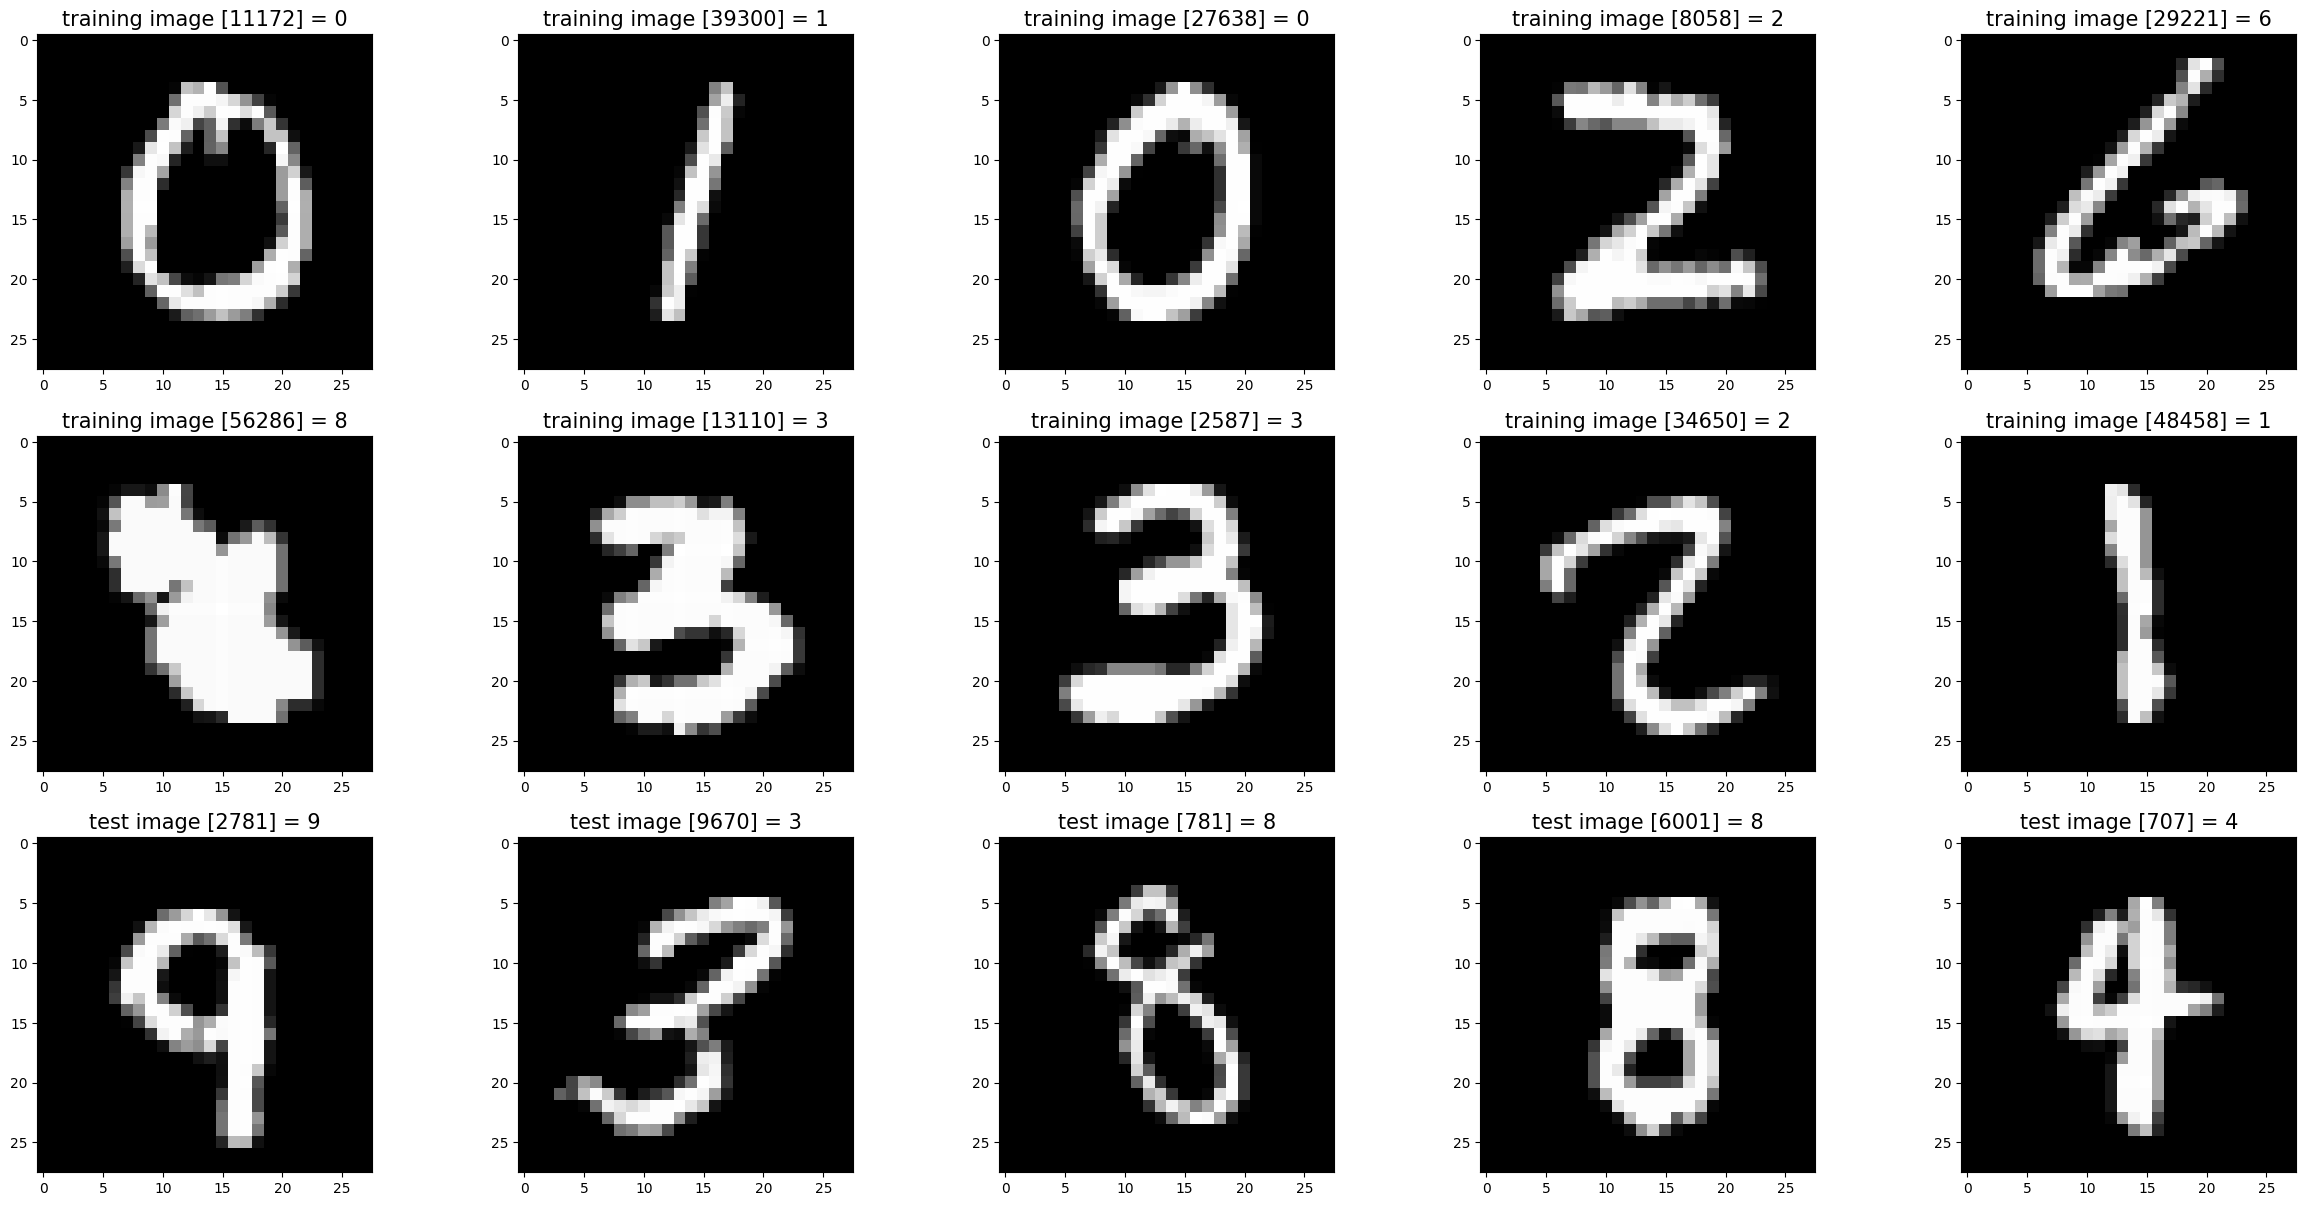

In [5]:
"""
## Visualize Sample Data
Show some random training and test images
"""

# Show some random training and test images 
images_2_show = []
titles_2_show = []

for i in range(0, 10):
    r = random.randint(1, 60000-1)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000-1)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

## PyTorch Dataset Class

### PyTorch Dataset Interface

- Must implement `__len__` and `__getitem__`
- Enables automatic batching, shuffling, and parallel loading

### Normalization

- `self.images = images.astype(np.float32) / 255.0`
- Converts uint8 (0-255) to float32 (0.0-1.0)
- Neural networks train better with normalized inputs
- Prevents gradient explosion

### Channel Dimension

- `image = np.expand_dims(image, axis=0)`
- PyTorch expects: (Channels, Height, Width)
- MNIST is grayscale: 1 channel
- Shape: (28, 28) → (1, 28, 28)

### DataLoader Creation

- `train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)`
- `batch_size=128`: Process 128 images at once
- `shuffle=True`: Randomize order each epoch
- Handles batching automatically

### Why This Design

- Separates data loading from model logic
- Efficient memory usage (loads on-demand)
- Standard PyTorch pattern

In [6]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        # Normalize images to [0, 1]
        self.images = images.astype(np.float32) / 255.0
        self.labels = labels
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Get image and label
        image = self.images[idx]
        label = self.labels[idx]
        
        # Add channel dimension: (28, 28) -> (1, 28, 28)
        image = np.expand_dims(image, axis=0)
        
        # Convert to PyTorch tensors
        image = torch.from_numpy(image)
        label = torch.tensor(label, dtype=torch.long)
        
        return image, label

# Create PyTorch datasets
train_dataset = MNISTDataset(x_train, y_train)
test_dataset = MNISTDataset(x_test, y_test)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Verify data loader
sample_batch = next(iter(train_loader))
print(f"\nBatch image shape: {sample_batch[0].shape}")
print(f"Batch label shape: {sample_batch[1].shape}")

Number of training batches: 469
Number of test batches: 79

Batch image shape: torch.Size([128, 1, 28, 28])
Batch label shape: torch.Size([128])


## Multi-Layer Perceptron Model Definition

### Network Structure

- Input: 784 neurons (28×28 flattened)
- Hidden Layer 1: 256 neurons
- Hidden Layer 2: 128 neurons
- Output: 10 neurons (one per digit)

### Layer Calculations

- Layer 1: 784 × 256 + 256 = 200,960 parameters
- Layer 2: 256 × 128 + 128 = 32,896 parameters
- Layer 3: 128 × 10 + 10 = 1,290 parameters
- Total: 235,146 parameters

### Forward Pass

- `view(x.size(0), -1)`: Flattens keeping batch dimension
- `F.relu`: Rectified Linear Unit activation
- `dropout`: Randomly zeros 20% of neurons (training only)

### Why This Architecture

- Simple enough to train quickly
- Complex enough for good accuracy
- Dropout prevents overfitting
- Two hidden layers capture non-linear patterns

In [7]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size1=256, hidden_size2=128, num_classes=10):
        super(MLP, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, num_classes)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        # Flatten the input: (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)
        
        # Layer 1
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Output layer (no activation - will use CrossEntropyLoss)
        x = self.fc3(x)
        
        return x

# Create model instance
model = MLP().to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 235,146
Trainable parameters: 235,146


## Training Configuration

Set up loss function, optimizer, and training parameters

### CrossEntropyLoss

- Combines LogSoftmax and NLLLoss
- Perfect for multi-class classification
- Expects raw scores (logits), not probabilities
- Formula: -log(exp(x[correct_class]) / sum(exp(x)))

### Adam Optimizer

- Adaptive Moment Estimation
- Combines momentum with adaptive learning rates
- Good default choice for most problems
- `lr=0.001`: Standard starting learning rate

### Learning Rate Scheduler

- `StepLR(optimizer, step_size=5, gamma=0.5)`
- Reduces LR by 50% every 5 epochs
- Helps fine-tune as training progresses
- New LR = Old LR × 0.5

### Why These Choices

- CrossEntropyLoss: Industry standard for classification
- Adam: Robust, works well out-of-the-box
- Scheduler: Prevents overshooting optimal weights

In [8]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training parameters
num_epochs = 15

# Storage for metrics
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Print configuration
print("Training Configuration:")
print(f"  Loss Function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr={0.001})")
print(f"  Scheduler: StepLR (step_size=5, gamma=0.5)")
print(f"  Number of epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print("\nTraining setup complete!")

Training Configuration:
  Loss Function: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: StepLR (step_size=5, gamma=0.5)
  Number of epochs: 15
  Batch size: 128

Training setup complete!


## Training and Evaluation Functions

### Model Modes

- `model.train()`: Enables dropout, batch norm updates
- `model.eval()`: Disables dropout, freezes batch norm

### Device Transfer

    data, target = data.to(device), target.to(device)

- Moves data to GPU if available
- Must be same device as model

### Gradient Management

- optimizer.zero_grad() - Clear previous gradients
- loss.backward() - Compute gradients
- optimizer.step() - Update weights
- PyTorch accumulates gradients by default
- Must clear before each batch

### Evaluation Function

    with torch.no_grad():
        for data, target in test_loader:
            pass

- no_grad(): Disables gradient computation
- Saves memory and speeds up inference

### Metrics Tracking

- Loss: Average over all batches
- Accuracy: Percentage of correct predictions
- Returns both for plotting

In [9]:
def train_epoch(model, device, train_loader, optimizer, criterion, epoch):
    """Train model for one epoch"""
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        # Forward pass
        output = model(data)
        loss = criterion(output, target)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate metrics
        train_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
        
        # Update progress bar
        if batch_idx % 10 == 0:
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
    
    avg_loss = train_loss / len(train_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy

def evaluate(model, device, test_loader, criterion):
    """Evaluate model on test set"""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            test_loss += criterion(output, target).item()
            
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy, np.array(all_predictions), np.array(all_targets)

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## Train the MLP model and track performance metrics

### Training Process

**Epoch Loop**

- One epoch = one pass through the entire dataset
- 15 epochs are typical for MNIST
- More epochs risk overfitting

**Training vs Validation**

- Training: Update weights, measure performance
- Validation: Only measure, no updates
- Gap indicates overfitting

**Learning Rate Decay**

    scheduler.step()  # after each epoch

- Gradual reduction helps convergence

In [10]:
print("Starting training...\n")

for epoch in range(1, num_epochs + 1):
    # Train for one epoch
    train_loss, train_acc = train_epoch(
        model, device, train_loader, optimizer, criterion, epoch
    )
    
    # Evaluate on test set
    test_loss, test_acc, _, _ = evaluate(model, device, test_loader, criterion)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # Update learning rate
    scheduler.step()
    
    # Print epoch summary
    print(f'\nEpoch {epoch}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(f'  Learning Rate: {scheduler.get_last_lr()[0]:.6f}')
    print('-' * 50)

Starting training...



Epoch 1: 100%|██████████| 469/469 [00:03<00:00, 121.34it/s, Loss=0.3008, Acc=88.24%]



Epoch 1/15:
  Train Loss: 0.3936, Train Acc: 88.35%
  Test Loss: 0.1595, Test Acc: 95.00%
  Learning Rate: 0.001000
--------------------------------------------------


Epoch 2: 100%|██████████| 469/469 [00:03<00:00, 121.98it/s, Loss=0.1015, Acc=95.24%]



Epoch 2/15:
  Train Loss: 0.1579, Train Acc: 95.24%
  Test Loss: 0.1105, Test Acc: 96.58%
  Learning Rate: 0.001000
--------------------------------------------------


...


Epoch 13/15:
  Train Loss: 0.0228, Train Acc: 99.30%
  Test Loss: 0.0568, Test Acc: 98.30%
  Learning Rate: 0.000250
--------------------------------------------------


Epoch 14: 100%|██████████| 469/469 [00:03<00:00, 124.21it/s, Loss=0.0159, Acc=99.33%]



Epoch 14/15:
  Train Loss: 0.0212, Train Acc: 99.33%
  Test Loss: 0.0593, Test Acc: 98.35%
  Learning Rate: 0.000250
--------------------------------------------------


Epoch 15: 100%|██████████| 469/469 [00:03<00:00, 123.83it/s, Loss=0.0148, Acc=99.34%]



Epoch 15/15:
  Train Loss: 0.0200, Train Acc: 99.34%
  Test Loss: 0.0582, Test Acc: 98.25%
  Learning Rate: 0.000125
--------------------------------------------------


## Visualize Training History

### Interpreting the Plots

**Loss Curves**

- Should decrease over time
- Training loss < Test loss (normal)
- Large gap = overfitting

**Accuracy Curves**

- Should increase and plateau
- Test accuracy slightly lower than train
- Plateau indicates convergence

**What to Look For**

- Smooth curves: Good learning rate
- Erratic curves: Learning rate too high
- No improvement: Learning rate too low
- Diverging train/test: Overfitting

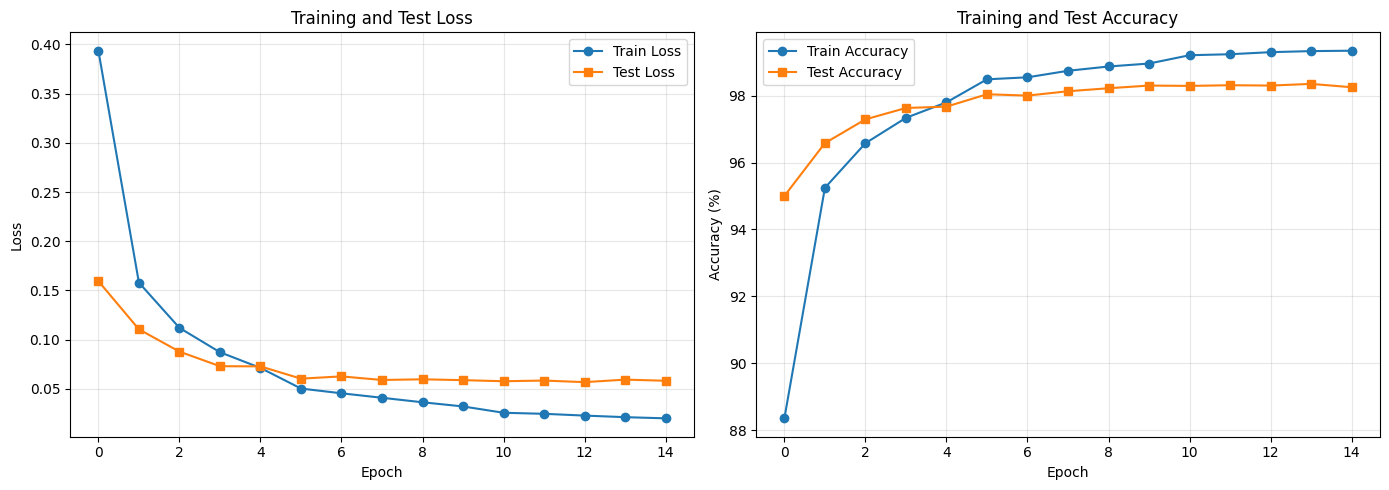


Best Test Accuracy: 98.35% at Epoch 14


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(test_accuracies, label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Test Accuracy: {max(test_accuracies):.2f}% at Epoch {test_accuracies.index(max(test_accuracies)) + 1}")

## Model Evaluation with Confusion Matrix

### Confusion Matrix Analysis

**Reading the Matrix**

- Rows: True labels
- Columns: Predicted labels
- Diagonal: Correct predictions
- Off-diagonal: Errors

**Common Confusions**

- 4 ↔ 9: Similar shape
- 3 ↔ 5: Curved tops
- 2 ↔ 7: Handwriting variations

**Classification Report**

- precision = TP / (TP + FP)
- recall = TP / (TP + FN)
- f1-score = 2 * (precision * recall) / (precision + recall)

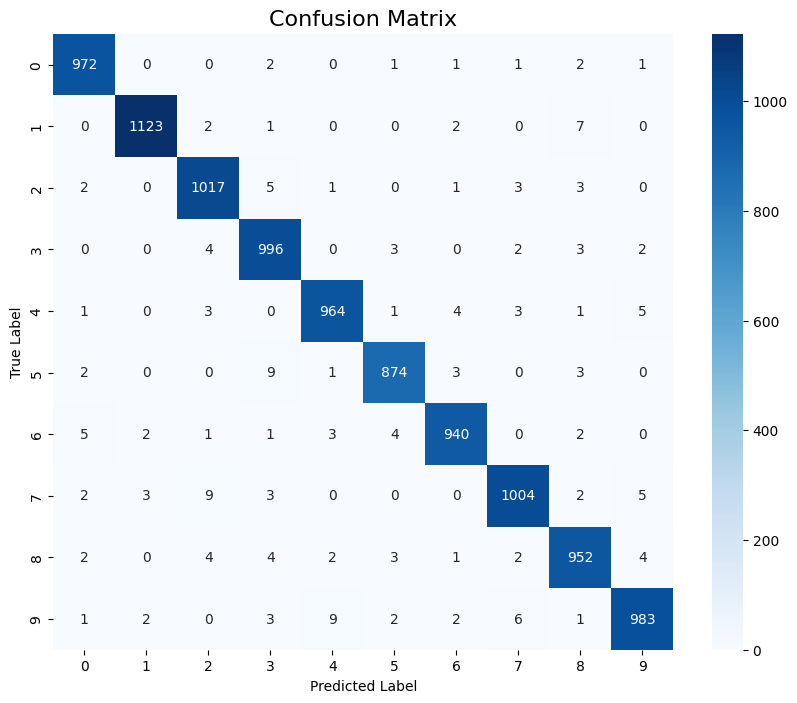


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [12]:
# Get final predictions
_, _, predictions, targets = evaluate(model, device, test_loader, criterion)

# Confusion Matrix
cm = confusion_matrix(targets, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(targets, predictions))

## Visualize Model Predictions

Show some examples of model predictions with confidence scores

### Softmax Output

- Converts logits to probabilities
- Sum to 1.0 across classes
- Higher = more confident

### Prediction Analysis

- High confidence + correct = Good
- High confidence + wrong = Problematic
- Low confidence = Ambiguous input

Sample Model Predictions:


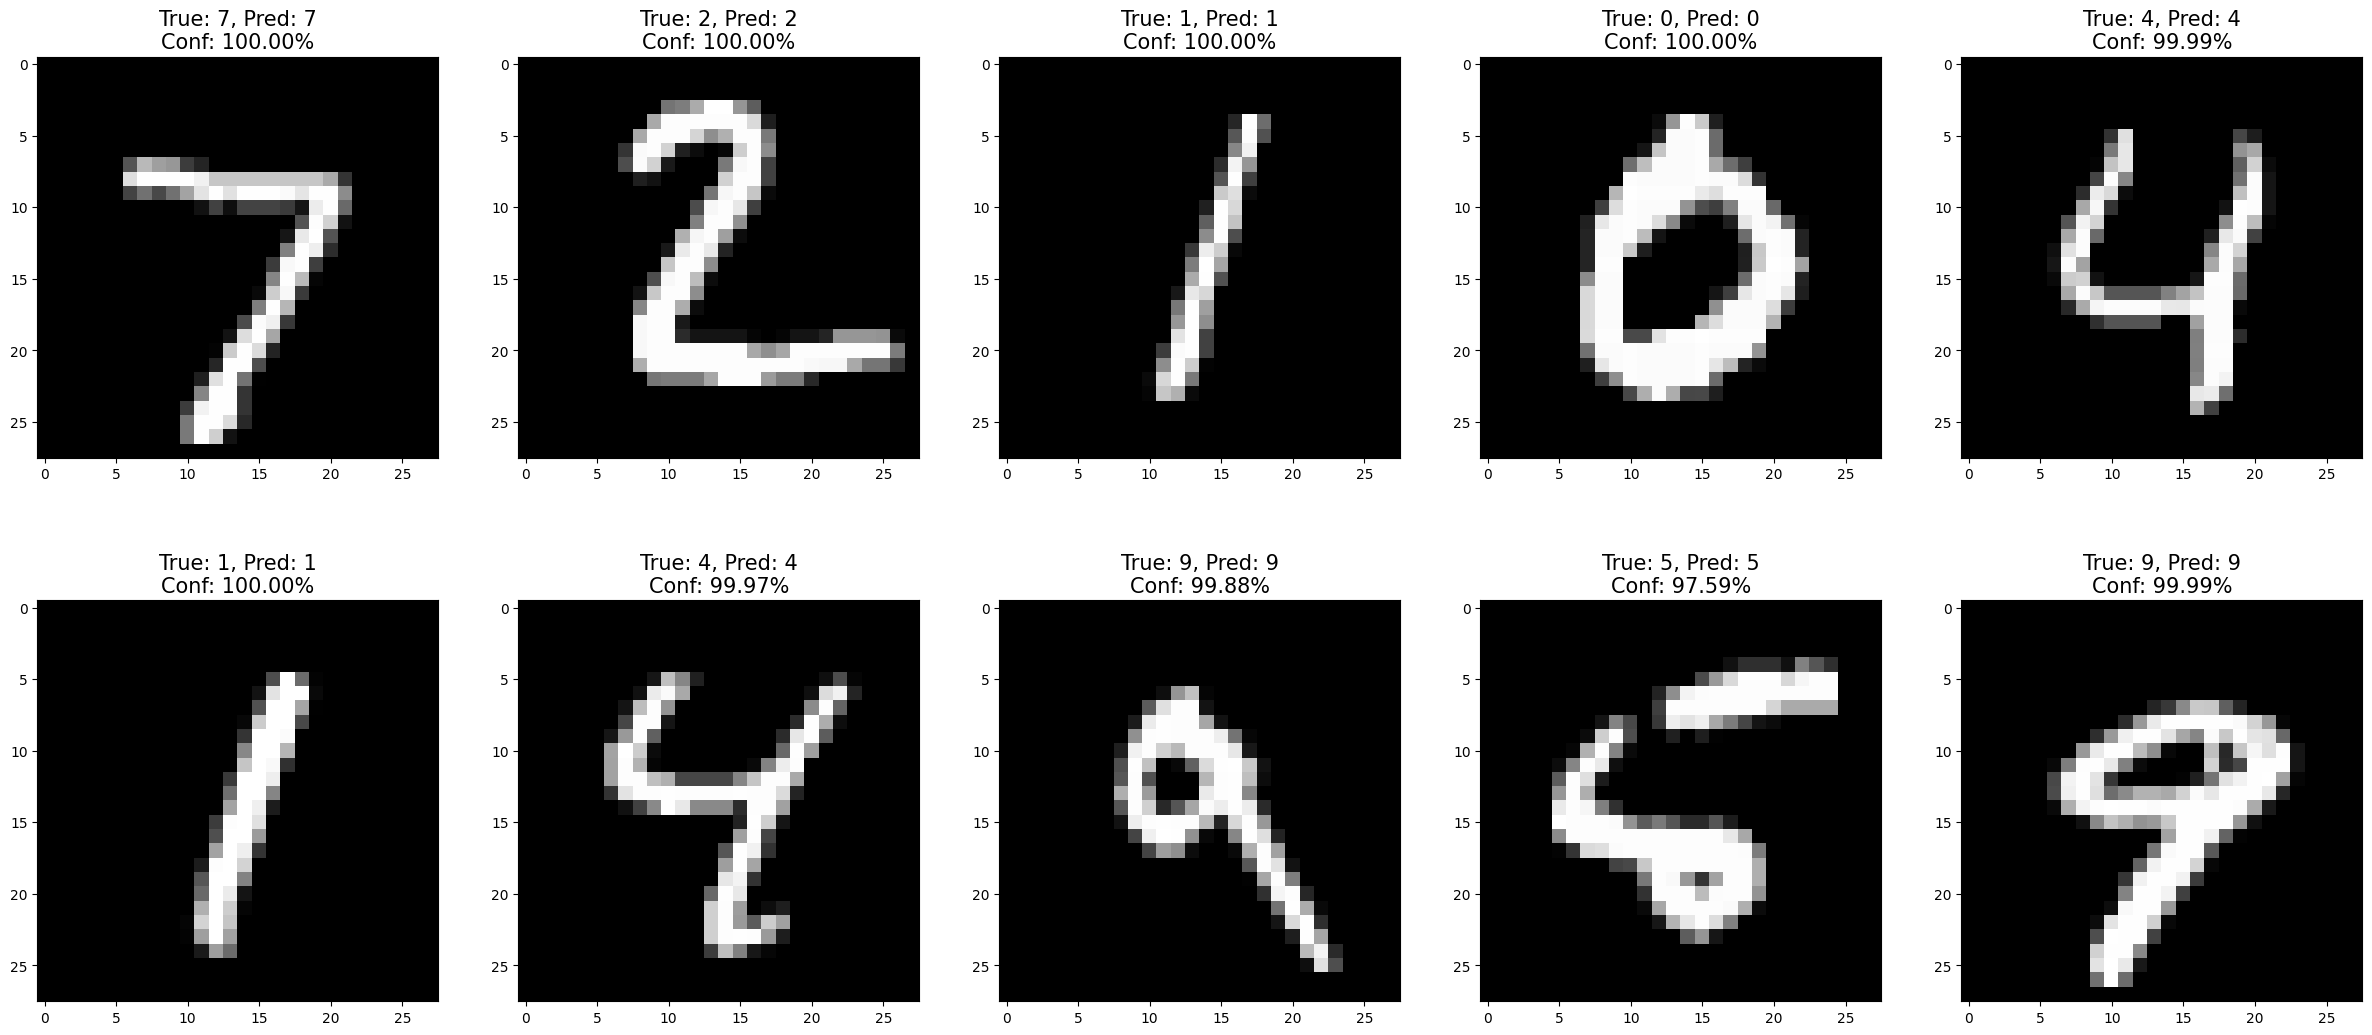

In [13]:
def show_model_predictions(model, test_loader, device, num_images=10):
    """Display model predictions on test images"""
    model.eval()
    
    # Get one batch
    images, labels = next(iter(test_loader))
    images, labels = images[:num_images].to(device), labels[:num_images]
    
    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        _, predicted = outputs.max(1)
        probs = F.softmax(outputs, dim=1)
    
    # Convert images back to numpy for visualization
    images_np = images.cpu().numpy()
    
    # Plot
    images_to_show = []
    titles_to_show = []
    
    for i in range(num_images):
        # Get confidence
        confidence = probs[i, predicted[i]].item()
        
        # Prepare image (remove channel dimension)
        img = images_np[i].squeeze()
        
        # Create title
        true_label = labels[i].item()
        pred_label = predicted[i].item()
        
        if true_label == pred_label:
            title = f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2%}'
        else:
            title = f'True: {true_label}, Pred: {pred_label} (WRONG)\nConf: {confidence:.2%}'
        
        images_to_show.append(img)
        titles_to_show.append(title)
    
    show_images(images_to_show, titles_to_show)

print("Sample Model Predictions:")
show_model_predictions(model, test_loader, device)

## Error Analysis

Analyze which digits are most commonly misclassified

### Per-Class Performance

- Some digits are easier (0, 1)
- Some harder (8, 9)
- Reveals data or model biases

### Confusion Pairs

    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

- Normalizes by true class frequency
- Shows the percentage confused
- Identifies systematic issues

### Improvement Strategies

- Data augmentation for confused pairs
- Class weights for imbalanced data
- Architecture changes for hard cases

In [14]:
# Calculate per-class accuracy
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == target).squeeze()
        
        for i in range(target.size(0)):
            label = target[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Print per-class accuracy
print("Per-class Accuracy:")
print("-" * 30)
for i in range(10):
    accuracy = 100 * class_correct[i] / class_total[i]
    print(f'Digit {i}: {accuracy:.2f}% ({int(class_correct[i])}/{int(class_total[i])})')
    
# Find most confused pairs
print("\nMost Confused Pairs:")
print("-" * 30)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
np.fill_diagonal(cm_normalized, 0)  # Remove correct predictions

confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_normalized[i, j] > 0.01:  # More than 1% confusion
            confused_pairs.append((i, j, cm_normalized[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_label, pred_label, conf_rate in confused_pairs[:10]:
    print(f"{true_label} → {pred_label}: {conf_rate*100:.1f}%")

Per-class Accuracy:
------------------------------
Digit 0: 99.18% (972/980)
Digit 1: 98.94% (1123/1135)
Digit 2: 98.55% (1017/1032)
Digit 3: 98.61% (996/1010)
Digit 4: 98.17% (964/982)
Digit 5: 97.98% (874/892)
Digit 6: 98.12% (940/958)
Digit 7: 97.67% (1004/1028)
Digit 8: 97.74% (952/974)
Digit 9: 97.42% (983/1009)

Most Confused Pairs:
------------------------------
5 → 3: 1.0%


## Save Training Model

### What to Save

- Model weights (state_dict)
- Optimizer state (for resuming)
- Training metadata
- Performance metrics

### File Formats

- `.pth`: PyTorch native format
- `.json`: Human-readable metadata
- `.npz`: NumPy arrays (optional)

### Loading Later

    checkpoint = torch.load('model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

In [15]:
# Create directory for saving
import os
save_dir = 'mnist_mlp_model'
os.makedirs(save_dir, exist_ok=True)

# Save model
model_path = os.path.join(save_dir, 'mnist_mlp.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'train_loss': train_losses[-1],
    'test_loss': test_losses[-1],
    'train_acc': train_accuracies[-1],
    'test_acc': test_accuracies[-1],
}, model_path)

print(f"Model saved to: {model_path}")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")

# Save training history
import json

history = {
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'test_losses': test_losses,
    'test_accuracies': test_accuracies
}

with open(os.path.join(save_dir, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print("Training history saved!")

Model saved to: mnist_mlp_model/mnist_mlp.pth
Final Test Accuracy: 98.25%
Training history saved!
